# Cardiac Patient Monitoring System

**Objective:** classify a synthetic elevated cardiac-risk pattern and explore structure among synthetic patient-like observations. The target is educational and is not a diagnosis. This notebook uses only synthetic data and must not be used for treatment, emergency guidance, or real patient care.

It covers environment checks, cleaning, statistics and EDA, feature engineering, two classification pipelines, stratified cross-validation, held-out evaluation, PCA, a comparison of K-means, DBSCAN, and hierarchical clustering, findings, and limitations.

## 1. Environment and reproducibility

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.environ['MPLCONFIGDIR'] = str(PROJECT_ROOT / '.matplotlib')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve, silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = '../data/cardiac_patients_raw.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Dataset and target definition

The data is created by `src/generate_data.py` with seed 42. It resembles common tabular cardiac datasets but contains no real patients. `cardiac_risk` is the binary target: **0 = lower simulated pattern** and **1 = elevated simulated pattern**. `patient_id` is only a synthetic identifier and is excluded from all models.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.info())
display(df.dtypes.rename('dtype').to_frame())
df.head()

dataset shape: 1,215 rows x 11 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1215 non-null   object 
 1   age                  1215 non-null   float64
 2   sex                  1215 non-null   object 
 3   resting_bp           1184 non-null   float64
 4   cholesterol          1185 non-null   float64
 5   bmi                  1185 non-null   float64
 6   fasting_blood_sugar  1215 non-null   int64  
 7   max_heart_rate       1183 non-null   float64
 8   exercise_angina      1215 non-null   object 
 9   chest_pain_type      1184 non-null   object 
 10  cardiac_risk         1215 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 104.5+ KB


None

,dtype
patient_id,object
age,float64
sex,object
resting_bp,float64
cholesterol,float64
bmi,float64
fasting_blood_sugar,int64
max_heart_rate,float64
exercise_angina,object
chest_pain_type,object


,patient_id,age,sex,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate,exercise_angina,chest_pain_type,cardiac_risk
0,SYN-0001,34.0,Female,155.5,200.5,32.1,1,141.6,No,Atypical,0
1,SYN-0002,73.0,Male,117.0,224.7,32.2,1,117.0,No,Non-anginal,1
2,SYN-0003,66.0,Male,131.5,287.9,29.5,1,138.9,No,Asymptomatic,1
3,SYN-0004,54.0,Male,109.5,159.0,21.5,0,145.0,No,Atypical,0
4,SYN-0005,54.0,Male,115.5,206.2,21.6,0,156.0,No,Asymptomatic,1


## 3. Data preparation and quality audit

Exact duplicates are removed. Impossible or highly implausible numeric values are converted to missing values using the documented ranges, and invalid categories are also converted to missing. Missing predictor values are intentionally **not filled globally**: each pipeline learns its imputation values from training data only, which avoids data leakage.

In [3]:
duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

valid_ranges = {
    'age': (18, 100), 'resting_bp': (70, 250), 'cholesterol': (80, 600),
    'bmi': (10, 60), 'fasting_blood_sugar': (0, 1), 'max_heart_rate': (50, 250),
}
invalid_report = {}
for column, (lower, upper) in valid_ranges.items():
    invalid_mask = df[column].notna() & ~df[column].between(lower, upper)
    invalid_report[column] = int(invalid_mask.sum())
    df.loc[invalid_mask, column] = np.nan

valid_categories = {
    'sex': {'Female', 'Male'},
    'exercise_angina': {'No', 'Yes'},
    'chest_pain_type': {'Typical', 'Atypical', 'Non-anginal', 'Asymptomatic'},
}
for column, allowed in valid_categories.items():
    invalid_mask = df[column].notna() & ~df[column].isin(allowed)
    invalid_report[column] = int(invalid_mask.sum())
    df.loc[invalid_mask, column] = np.nan

df = df[df['cardiac_risk'].isin([0, 1])].copy()
df['cardiac_risk'] = df['cardiac_risk'].astype(int)

quality_summary = pd.DataFrame({
    'missing_after_validation': df.isna().sum(),
    'missing_percent': (100 * df.isna().mean()).round(2),
})
print(f'Exact duplicates removed: {duplicate_count}')
print(f'Cleaned shape before pipeline imputation: {df.shape}')
print('Invalid values converted to missing:', invalid_report)
display(quality_summary)

Exact duplicates removed: 15
Cleaned shape before pipeline imputation: (1200, 11)
Invalid values converted to missing: {'age': 2, 'resting_bp': 2, 'cholesterol': 2, 'bmi': 2, 'fasting_blood_sugar': 0, 'max_heart_rate': 2, 'sex': 0, 'exercise_angina': 0, 'chest_pain_type': 1}


,missing_after_validation,missing_percent
patient_id,0,0.00
age,2,0.17
sex,0,0.00
resting_bp,32,2.67
cholesterol,32,2.67
bmi,32,2.67
fasting_blood_sugar,0,0.00
max_heart_rate,32,2.67
exercise_angina,0,0.00
chest_pain_type,31,2.58


## 4. Descriptive statistics, probability, and exploratory analysis

The analysis checks class balance, central tendency and spread, a conditional probability, potential outliers, pairwise correlations, and relationships with the target. Visual patterns describe this synthetic sample only and do not establish causation.

In [4]:
numeric_columns = ['age', 'resting_bp', 'cholesterol', 'bmi', 'fasting_blood_sugar', 'max_heart_rate']
display(df[numeric_columns + ['cardiac_risk']].describe().T.round(2))

class_balance = df['cardiac_risk'].value_counts().sort_index().rename(index={0: 'Lower pattern', 1: 'Elevated pattern'})
print('Class counts:')
display(class_balance.to_frame('count').assign(percent=lambda x: (100 * x['count'] / x['count'].sum()).round(1)))

conditional_risk = pd.crosstab(df['exercise_angina'], df['cardiac_risk'], normalize='index')
print('Conditional probability P(cardiac_risk = 1 | exercise_angina):')
display(conditional_risk.rename(columns={0: 'P(lower)', 1: 'P(elevated)'}).round(3))

conditional_risk = pd.crosstab(df['sex'], df['cardiac_risk'], normalize='index')
print('Conditional probability P(cardiac_risk = 1 | sex):')
display(conditional_risk.rename(columns={0: 'P(lower)', 1: 'P(elevated)'}).round(3))

print('Numeric means grouped by target:')
display(df.groupby('cardiac_risk')[numeric_columns].mean().rename(index={0: 'Lower', 1: 'Elevated'}).round(2))

,count,mean,std,min,25%,50%,75%,max
age,1198.0,57.73,16.11,30.0,44.00,58.00,72.00,85.0
resting_bp,1168.0,128.02,15.73,85.0,117.68,128.25,138.90,176.4
cholesterol,1168.0,209.88,38.36,105.0,183.00,208.80,234.90,340.0
bmi,1168.0,27.23,4.23,16.0,24.30,27.30,30.02,40.7
fasting_blood_sugar,1200.0,0.22,0.41,0.0,0.00,0.00,0.00,1.0
max_heart_rate,1168.0,139.20,16.86,90.9,127.40,138.70,150.72,197.8
cardiac_risk,1200.0,0.50,0.50,0.0,0.00,1.00,1.00,1.0


Class counts:


,count,percent
cardiac_risk,,
Lower pattern,594,49.5
Elevated pattern,606,50.5


Conditional probability P(cardiac_risk = 1 | exercise_angina):


cardiac_risk,P(lower),P(elevated)
exercise_angina,,
No,0.580,0.420
Yes,0.284,0.716


Conditional probability P(cardiac_risk = 1 | sex):


cardiac_risk,P(lower),P(elevated)
sex,,
Female,0.524,0.476
Male,0.467,0.533


Numeric means grouped by target:


,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate
cardiac_risk,,,,,,
Lower,49.86,124.29,200.41,26.40,0.13,145.85
Elevated,65.47,131.64,219.22,28.03,0.30,132.64


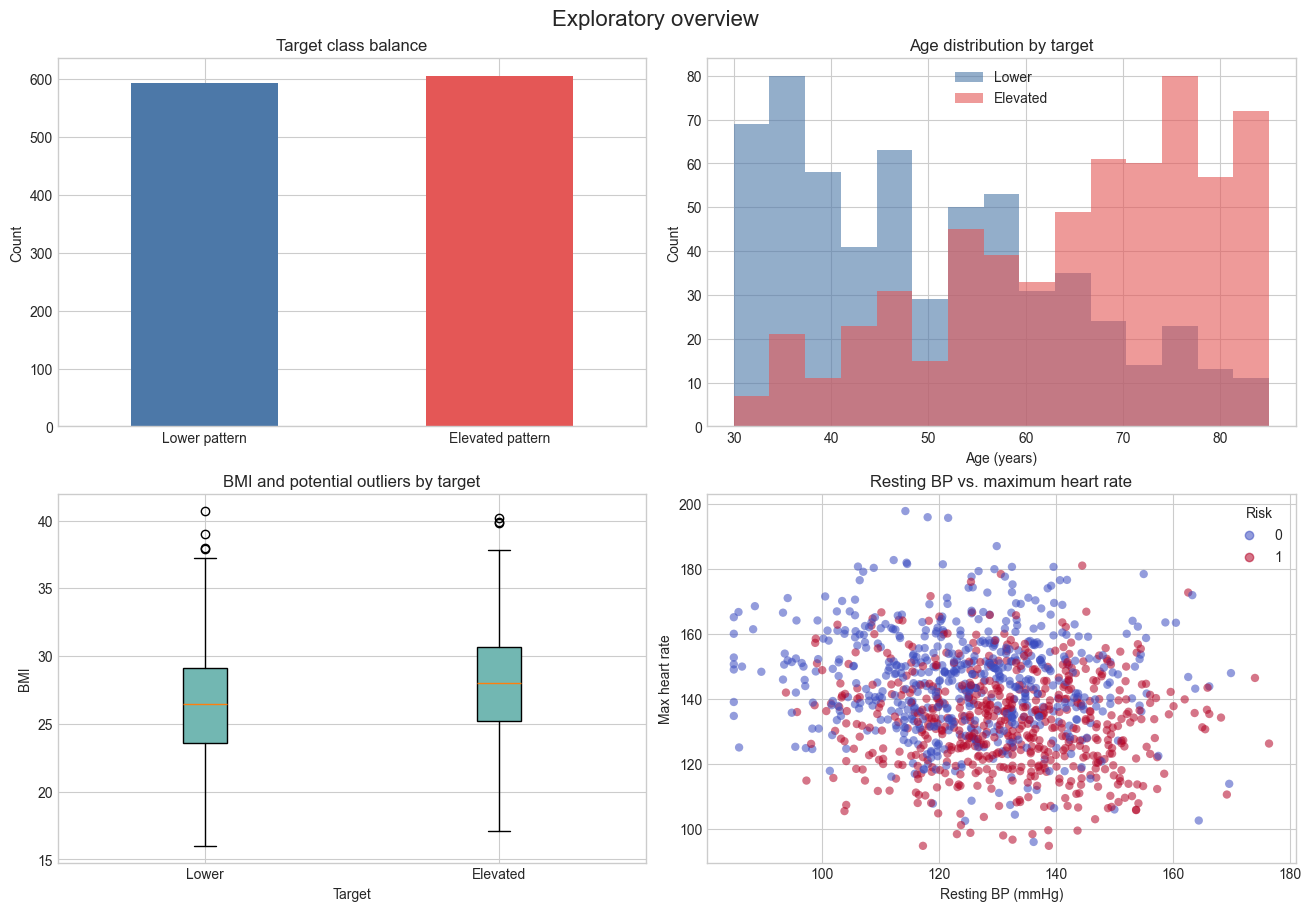

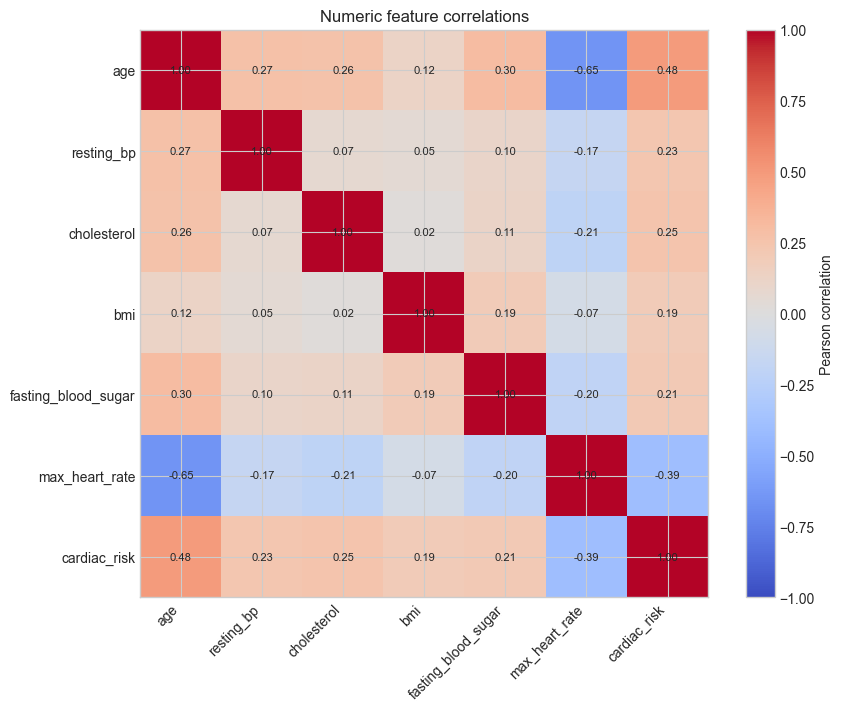

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
class_balance.plot(kind='bar', color=['#4C78A8', '#E45756'], ax=axes[0, 0])
axes[0, 0].set(title='Target class balance', xlabel='', ylabel='Count')
axes[0, 0].tick_params(axis='x', rotation=0)

for target, color, label in [(0, '#4C78A8', 'Lower'), (1, '#E45756', 'Elevated')]:
    axes[0, 1].hist(df.loc[df['cardiac_risk'] == target, 'age'].dropna(), bins=15, alpha=0.60, color=color, label=label)
axes[0, 1].set(title='Age distribution by target', xlabel='Age (years)', ylabel='Count')
axes[0, 1].legend()

box_data = [df.loc[df['cardiac_risk'] == target, 'bmi'].dropna() for target in [0, 1]]
axes[1, 0].boxplot(box_data, tick_labels=['Lower', 'Elevated'], patch_artist=True,
                   boxprops={'facecolor': '#72B7B2'})
axes[1, 0].set(title='BMI and potential outliers by target', xlabel='Target', ylabel='BMI')

scatter_data = df[['resting_bp', 'max_heart_rate', 'cardiac_risk']].dropna()
scatter = axes[1, 1].scatter(scatter_data['resting_bp'], scatter_data['max_heart_rate'], c=scatter_data['cardiac_risk'],
                              cmap='coolwarm', alpha=0.55, edgecolor='none')
axes[1, 1].set(title='Resting BP vs. maximum heart rate', xlabel='Resting BP (mmHg)', ylabel='Max heart rate')
axes[1, 1].legend(*scatter.legend_elements(), title='Risk')
fig.suptitle('Exploratory overview', fontsize=16)
fig.savefig(OUTPUT_DIR / 'eda_overview.png', dpi=160, bbox_inches='tight')
plt.show()

correlation = df[numeric_columns + ['cardiac_risk']].corr()
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
image = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
ax.set_yticks(range(len(correlation.index)), correlation.index)
for row in range(len(correlation.index)):
    for column in range(len(correlation.columns)):
        ax.text(column, row, f'{correlation.iloc[row, column]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='Pearson correlation')
ax.set_title('Numeric feature correlations')
fig.savefig(OUTPUT_DIR / 'correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

### Exploratory Overview

The target variable, `cardiac_risk`, is almost evenly distributed between the **Lower** and **Elevated** patterns. This is useful for classification because there is no major class imbalance that could strongly bias the model toward one class.

The age distribution shows a noticeable difference between the two target groups. Lower-risk observations appear more frequently among younger ages, while elevated-risk observations become more common at older ages. This suggests that `age` may be an important predictive feature.

The BMI box plot shows that the Elevated group has a slightly higher median BMI than the Lower group. However, there is considerable overlap between the two groups, meaning that BMI alone is unlikely to clearly separate the target classes. A few potential high-BMI outliers are also visible in both groups.

The scatter plot comparing `resting_bp` and `max_heart_rate` also shows substantial overlap between the two classes. However, elevated-risk observations tend to appear more frequently at lower maximum heart-rate values. Resting blood pressure by itself does not provide a clear visual separation between the two target groups.

Overall, the exploratory plots suggest that some features contain useful predictive information, but no single feature appears sufficient to separate the classes perfectly.

---

## Correlation Analysis

The correlation matrix was used to measure the linear relationships between the numerical features and the `cardiac_risk` target.

Among the available features, `age` has the strongest positive correlation with the target:

- `age`: **0.48**
- `cholesterol`: **0.25**
- `resting_bp`: **0.23**
- `fasting_blood_sugar`: **0.21**
- `bmi`: **0.19**

This indicates that higher values of these features are generally associated with the Elevated cardiac-risk pattern, although most of these relationships are relatively weak.

`max_heart_rate` has the strongest negative correlation with the target:

- `max_heart_rate`: **-0.39**

This suggests that lower maximum heart-rate values tend to be associated with the Elevated group, while higher values are more frequently associated with the Lower group.

Another notable relationship is between `age` and `max_heart_rate`, which have a correlation of approximately **-0.65**. This indicates a relatively strong negative linear relationship between these two features in the synthetic dataset.

The correlation results are consistent with the exploratory visualizations: age appears to be one of the most informative individual features, followed by maximum heart rate. However, none of the features has an extremely strong correlation with the target.

Therefore, the classification models are expected to benefit from combining information from multiple features rather than relying on a single variable.

> **Note:** Correlation describes association, not causation. These results are based on synthetic data and should be interpreted as part of an educational machine-learning analysis rather than as medical conclusions.

## 5. Supervised problem, feature engineering, and split

Two predictor-only features are added based on the EDA: an age-adjusted maximum heart-rate ratio (`max_heart_rate / (220 - age)`) and an age–blood-pressure interaction (`age * resting_bp`). The data is split once with stratification: 80% training and 20% final test. The test set is not used during model selection.

In [6]:
model_df = df.copy()
model_df['heart_rate_ratio'] = model_df['max_heart_rate'] / (220 - model_df['age'])
model_df['age_bp_interaction'] = model_df['age'] * model_df['resting_bp']

X = model_df.drop(columns=['patient_id', 'cardiac_risk'])
y = model_df['cardiac_risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_features_model = X.select_dtypes(include=np.number).columns.tolist()
print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')
print(f'Train elevated prevalence: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')
print('Numeric features:', numeric_features_model)
print('Categorical features:', categorical_features)

Train rows: 960 | Test rows: 240
Train elevated prevalence: 50.5% | Test: 50.4%
Numeric features: ['age', 'resting_bp', 'cholesterol', 'bmi', 'fasting_blood_sugar', 'max_heart_rate', 'heart_rate_ratio', 'age_bp_interaction']
Categorical features: ['sex', 'exercise_angina', 'chest_pain_type']


## 6. Reusable preprocessing pipelines and baseline

Numeric predictors receive median imputation and standardization. Categorical predictors receive most-frequent imputation and one-hot encoding. Every operation is inside the Pipeline, so cross-validation refits preprocessing within each training fold. Logistic Regression is the simple baseline; Random Forest is the nonlinear comparison.

In [7]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features_model),
    ('categorical', categorical_pipeline, categorical_features),
])

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', clone(preprocessor)),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=350, min_samples_leaf=3, class_weight='balanced',
            random_state=42, n_jobs=1,
        )),
    ]),
}

baseline = models['Logistic Regression']
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)
print('Baseline Logistic Regression held-out metrics:')
print(
    f'Accuracy={accuracy_score(y_test, baseline_predictions):.3f} | '
    f'Precision={precision_score(y_test, baseline_predictions):.3f} | '
    f'Recall={recall_score(y_test, baseline_predictions):.3f} | '
    f'F1={f1_score(y_test, baseline_predictions):.3f}'
)

Baseline Logistic Regression held-out metrics:
Accuracy=0.746 | Precision=0.742 | Recall=0.760 | F1=0.751


## 7. Cross-validation and consistent model comparison

Both classifiers are compared using the same five stratified cross-validation folds on the training data. ROC-AUC measures ranking performance across thresholds; precision measures how often elevated predictions are correct; recall measures how many elevated cases are identified; and F1 balances precision and recall. The model with the highest mean cross-validated ROC-AUC is selected. Only after model selection, the chosen model is trained on the full training set and evaluated once on the untouched test set.

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

records = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    record = {
        'model': model_name
    }

    for metric in scoring:
        record[f'cv_{metric}_mean'] = scores[f'test_{metric}'].mean()
        record[f'cv_{metric}_std'] = scores[f'test_{metric}'].std()

    records.append(record)


comparison = (
    pd.DataFrame(records)
    .set_index('model')
    .sort_values(
        'cv_roc_auc_mean',
        ascending=False
    )
)

comparison.to_csv(
    OUTPUT_DIR / 'model_comparison.csv'
)

print("Cross-Validation Model Comparison")
display(comparison.round(3))


best_name = comparison.index[0]
best_model = models[best_name]

print(
    f"\nSelected by mean CV ROC-AUC: {best_name}"
)

best_model.fit(
    X_train,
    y_train
)

predictions = best_model.predict(X_test)

probabilities = best_model.predict_proba(
    X_test
)[:, 1]


test_results = {
    'model': best_name,
    'test_accuracy': accuracy_score(
        y_test,
        predictions
    ),
    'test_precision': precision_score(
        y_test,
        predictions,
        zero_division=0
    ),
    'test_recall': recall_score(
        y_test,
        predictions,
        zero_division=0
    ),
    'test_f1': f1_score(
        y_test,
        predictions,
        zero_division=0
    ),
    'test_roc_auc': roc_auc_score(
        y_test,
        probabilities
    )
}

test_results_df = pd.DataFrame(
    [test_results]
).set_index('model')

print("\nFinal Test Set Results")
display(test_results_df.round(3))


test_results_df.to_csv(
    OUTPUT_DIR / 'final_test_results.csv'
)

Cross-Validation Model Comparison


,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
model,,,,,,,,,,
Logistic Regression,0.745,0.031,0.749,0.035,0.746,0.049,0.747,0.032,0.828,0.027
Random Forest,0.743,0.042,0.745,0.040,0.746,0.056,0.745,0.044,0.808,0.047



Selected by mean CV ROC-AUC: Logistic Regression

Final Test Set Results


,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
model,,,,,
Logistic Regression,0.746,0.742,0.76,0.751,0.828


## 8. Held-out evaluation, error meaning, and saved pipeline

Classification Report
--------------------------------------------------
                  precision    recall  f1-score   support

   Lower pattern      0.750     0.731     0.740       119
Elevated pattern      0.742     0.760     0.751       121

        accuracy                          0.746       240
       macro avg      0.746     0.746     0.746       240
    weighted avg      0.746     0.746     0.746       240

TN=87, FP=32, FN=29, TP=92
False positives: 32 lower-pattern records were flagged as elevated.
False negatives: 29 elevated-pattern records were missed; in a screening-style context these deserve attention.


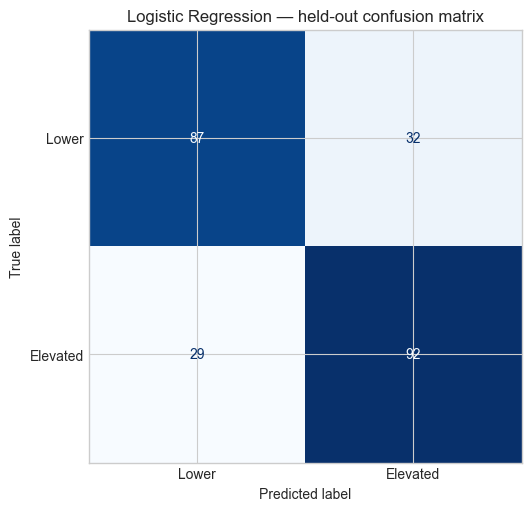

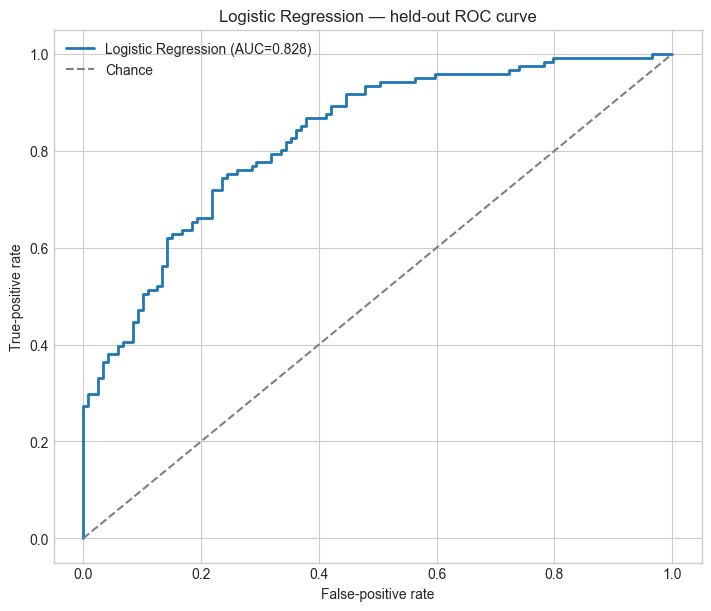

Saved complete fitted pipeline to: C:\Users\A TO Z\Desktop\Code\BinX_supervised_project\models\cardiac_risk_pipeline.joblib


In [9]:
best_predictions = best_model.predict(X_test)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]


print("Classification Report")
print("-" * 50)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            'Lower pattern',
            'Elevated pattern'
        ],
        digits=3
    )
)


matrix = confusion_matrix(
    y_test,
    best_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = matrix.ravel()

print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

print(
    f'False positives: {fp} lower-pattern records '
    'were flagged as elevated.'
)

print(
    f'False negatives: {fn} elevated-pattern records '
    'were missed; in a screening-style context '
    'these deserve attention.'
)


fig, ax = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True
)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['Lower', 'Elevated']
).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False
)

ax.set_title(
    f'{best_name} — held-out confusion matrix'
)

fig.savefig(
    OUTPUT_DIR / 'confusion_matrix.png',
    dpi=160,
    bbox_inches='tight'
)

plt.show()


false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    best_probabilities
)

area = roc_auc_score(
    y_test,
    best_probabilities
)

fig, ax = plt.subplots(
    figsize=(7, 6),
    constrained_layout=True
)

ax.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f'{best_name} (AUC={area:.3f})'
)

ax.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    label='Chance'
)

ax.set(
    xlabel='False-positive rate',
    ylabel='True-positive rate',
    title=f'{best_name} — held-out ROC curve'
)

ax.legend()

fig.savefig(
    OUTPUT_DIR / 'roc_curve.png',
    dpi=160,
    bbox_inches='tight'
)

plt.show()


model_path = (
    MODEL_DIR /
    'cardiac_risk_pipeline.joblib'
)

joblib.dump(
    best_model,
    model_path
)

print(
    f'Saved complete fitted pipeline to: '
    f'{model_path}'
)

## 9. Unsupervised exploration: K-means, DBSCAN, and hierarchical clustering

The target is excluded while fitting all three methods. Six numeric predictors are median-imputed and standardized so that features with large values do not dominate. Before fitting K-means, we test `k = 2` through `8`. The **elbow method** looks for the point where the drop in inertia starts slowing down, while the **silhouette score** prefers a larger value. Both support `k = 3` on this dataset. We then compare K-means, DBSCAN, and hierarchical clustering with the silhouette score. For DBSCAN, noise points (`-1`) are left out of its score, and the table shows how many rows it actually grouped. The method with the highest score is automatically selected and used for the final cluster column, summary, and PCA plot. PCA is used only to draw the two-dimensional picture. These groups are exploratory and must not be interpreted as clinical subtypes.

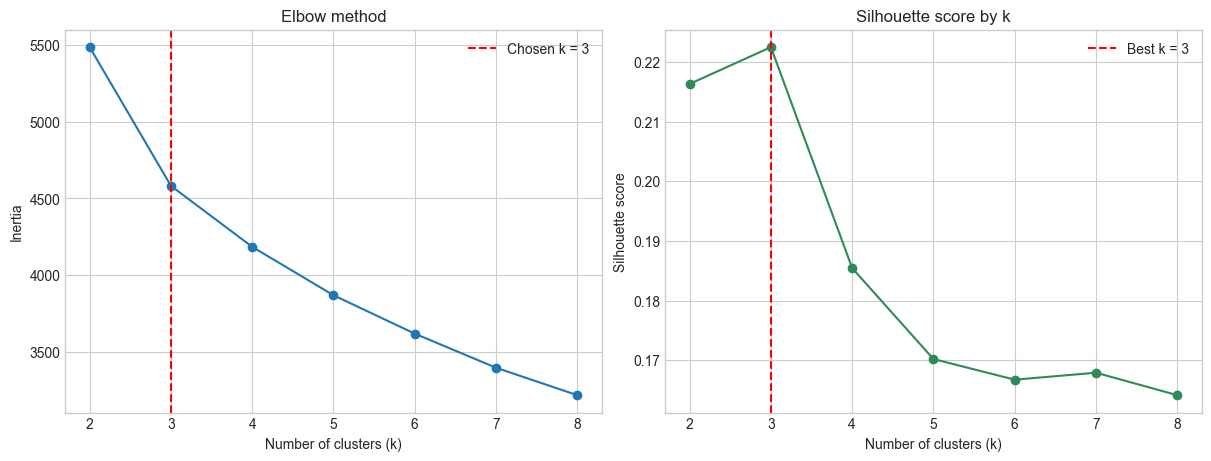

Chosen K-means k: 3


,k,inertia,silhouette_score
0,2,5487.385,0.216
1,3,4581.715,0.223
2,4,4183.641,0.185
3,5,3867.592,0.170
4,6,3616.996,0.167
5,7,3394.381,0.168
6,8,3215.245,0.164


Clustering comparison (higher silhouette score is better):


,method,clusters_found,silhouette_score,rows_grouped_percent,noise_points
0,DBSCAN,2,0.260,98.333,20
1,K-means,3,0.223,100.000,0
2,Hierarchical,3,0.172,100.000,0


Selected method: DBSCAN (silhouette=0.260)


,total_records,lower_count,lower_percent,elevated_count,elevated_percent,mean_age,mean_resting_bp,mean_cholesterol,mean_bmi,mean_max_heart_rate
cluster,,,,,,,,,,
-1,20,8,40.00,12,60.00,54.95,130.39,219.97,28.95,146.27
0,245,70,28.57,175,71.43,67.64,131.37,218.63,28.80,132.01
1,935,516,55.19,419,44.81,55.20,127.10,207.32,26.78,140.92


PCA variance explained: PC1=34.4%, PC2=17.6%
Total two-component variance: 52.0%


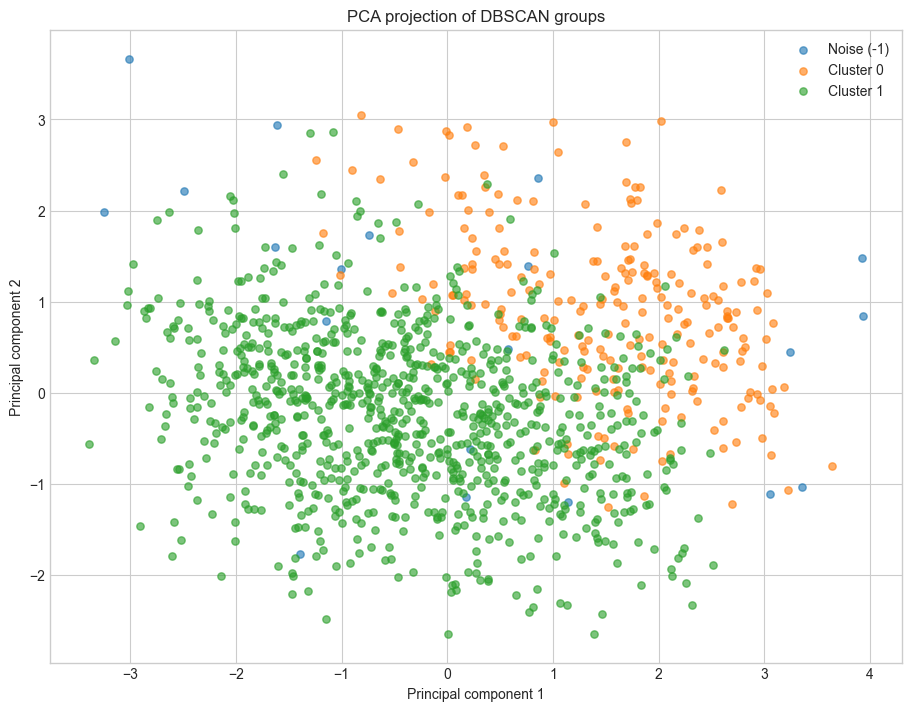

In [10]:
scaled_features = numeric_pipeline.fit_transform(df[numeric_columns])

k_values = range(2, 9)
k_results = []
for k in k_values:
    candidate = KMeans(n_clusters=k, n_init=20, random_state=42)
    candidate_labels = candidate.fit_predict(scaled_features)
    k_results.append({
        'k': k,
        'inertia': candidate.inertia_,
        'silhouette_score': silhouette_score(scaled_features, candidate_labels),
    })

k_selection = pd.DataFrame(k_results)
chosen_k = int(k_selection.loc[k_selection['silhouette_score'].idxmax(), 'k'])
k_selection.to_csv(OUTPUT_DIR / 'kmeans_k_selection.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(k_selection['k'], k_selection['inertia'], marker='o')
axes[0].axvline(chosen_k, color='red', linestyle='--', label=f'Chosen k = {chosen_k}')
axes[0].set(title='Elbow method', xlabel='Number of clusters (k)', ylabel='Inertia')
axes[0].legend()
axes[1].plot(k_selection['k'], k_selection['silhouette_score'], marker='o', color='#2E8B57')
axes[1].axvline(chosen_k, color='red', linestyle='--', label=f'Best k = {chosen_k}')
axes[1].set(title='Silhouette score by k', xlabel='Number of clusters (k)', ylabel='Silhouette score')
axes[1].legend()
fig.savefig(OUTPUT_DIR / 'kmeans_k_selection.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'Chosen K-means k: {chosen_k}')
display(k_selection.round(3))

clustering_labels = {
    'K-means': KMeans(n_clusters=chosen_k, n_init=20, random_state=42).fit_predict(scaled_features),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=10).fit_predict(scaled_features),
    'Hierarchical': AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(scaled_features),
}

comparison_rows = []
for method, labels in clustering_labels.items():
    grouped_mask = labels != -1
    grouped_labels = labels[grouped_mask]
    number_of_clusters = len(np.unique(grouped_labels))
    score = (
        silhouette_score(scaled_features[grouped_mask], grouped_labels)
        if number_of_clusters >= 2 else np.nan
    )
    comparison_rows.append({
        'method': method,
        'clusters_found': number_of_clusters,
        'silhouette_score': score,
        'rows_grouped_percent': 100 * grouped_mask.mean(),
        'noise_points': int((~grouped_mask).sum()),
    })

cluster_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values('silhouette_score', ascending=False)
    .reset_index(drop=True)
)
cluster_comparison.to_csv(OUTPUT_DIR / 'cluster_comparison.csv', index=False)
best_cluster_method = cluster_comparison.loc[0, 'method']
cluster_labels = clustering_labels[best_cluster_method]
silhouette = cluster_comparison.loc[0, 'silhouette_score']

print('Clustering comparison (higher silhouette score is better):')
display(cluster_comparison.round(3))
print(f'Selected method: {best_cluster_method} (silhouette={silhouette:.3f})')

clustered = df.copy()
clustered['cluster'] = cluster_labels
clustered.to_csv(OUTPUT_DIR / 'clustered_data.csv', index=False)
cluster_summary = clustered.groupby('cluster').agg(
    total_records=('cardiac_risk', 'size'),
    lower_count=('cardiac_risk', lambda values: (values == 0).sum()),
    elevated_count=('cardiac_risk', lambda values: (values == 1).sum()),
    mean_age=('age', 'mean'),
    mean_resting_bp=('resting_bp', 'mean'),
    mean_cholesterol=('cholesterol', 'mean'),
    mean_bmi=('bmi', 'mean'),
    mean_max_heart_rate=('max_heart_rate', 'mean'),
)
cluster_summary['lower_percent'] = (
    100 * cluster_summary['lower_count'] / cluster_summary['total_records']
)
cluster_summary['elevated_percent'] = (
    100 * cluster_summary['elevated_count'] / cluster_summary['total_records']
)
cluster_summary = cluster_summary[[
    'total_records', 'lower_count', 'lower_percent',
    'elevated_count', 'elevated_percent', 'mean_age',
    'mean_resting_bp', 'mean_cholesterol', 'mean_bmi',
    'mean_max_heart_rate',
]].round(2)
cluster_summary.to_csv(OUTPUT_DIR / 'cluster_summary.csv')
display(cluster_summary)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(scaled_features)
print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total two-component variance: {pca.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
for cluster in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == cluster
    label = 'Noise (-1)' if cluster == -1 else f'Cluster {cluster}'
    ax.scatter(components[mask, 0], components[mask, 1], s=28, alpha=0.62, label=label)
ax.set(xlabel='Principal component 1', ylabel='Principal component 2',
       title=f'PCA projection of {best_cluster_method} groups')
ax.legend()
fig.savefig(OUTPUT_DIR / 'pca_clusters.png', dpi=160, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 80)
print("COMPLETE MACHINE LEARNING PIPELINE — CARDIAC PATIENT MONITORING")
print("=" * 80)

print("\n📊 DATASET OVERVIEW")
print("-" * 80)
summary_data = {
    'Metric': ['Total Records', 'Training Set', 'Test Set', 'Features Used', 'Target Classes'],
    'Value': [f"{len(df):,}", f"{len(X_train):,}", f"{len(X_test):,}", 
              f"{X_train.shape[1]}", "2 (Binary Classification)"]
}
print(pd.DataFrame(summary_data).to_string(index=False))

print("\n⚖️  CLASS DISTRIBUTION")
print("-" * 80)
class_dist = {
    'Class': ['Lower Pattern', 'Elevated Pattern'],
    'Train Count': [f"{(y_train == 0).sum():,}", f"{(y_train == 1).sum():,}"],
    'Train %': [f"{100 * (y_train == 0).mean():.1f}%", f"{100 * (y_train == 1).mean():.1f}%"],
    'Test Count': [f"{(y_test == 0).sum():,}", f"{(y_test == 1).sum():,}"],
    'Test %': [f"{100 * (y_test == 0).mean():.1f}%", f"{100 * (y_test == 1).mean():.1f}%"]
}
print(pd.DataFrame(class_dist).to_string(index=False))

print("\n🎯 CROSS-VALIDATION RESULTS (5-Fold Stratified)")
print("-" * 80)
cv_summary = comparison.copy()
cv_summary = cv_summary.round(3)
print(cv_summary.to_string())

print(f"\n✅ SELECTED MODEL: {best_name}")
print("   Selection Criteria: Highest mean cross-validated ROC-AUC")

print("\n🧪 HELD-OUT TEST SET PERFORMANCE")
print("-" * 80)
test_metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [
        f"{accuracy_score(y_test, best_predictions):.3f}",
        f"{precision_score(y_test, best_predictions):.3f}",
        f"{recall_score(y_test, best_predictions):.3f}",
        f"{f1_score(y_test, best_predictions):.3f}",
        f"{roc_auc_score(y_test, best_probabilities):.3f}"
    ]
}
print(pd.DataFrame(test_metrics).to_string(index=False))

print("\n🔍 ERROR ANALYSIS")
print("-" * 80)
tn, fp, fn, tp = confusion_matrix(y_test, best_predictions).ravel()
error_analysis = {
    'Type': ['True Positives', 'True Negatives', 'False Positives', 'False Negatives'],
    'Count': [tp, tn, fp, fn],
    'Interpretation': [
        'Correctly identified elevated risk',
        'Correctly identified lower risk',
        'Incorrectly flagged as elevated (Type I error)',
        'Missed elevated risk cases (Type II error)'
    ]
}
print(pd.DataFrame(error_analysis).to_string(index=False))

print("\n🔗 CORRELATION WITH TARGET (Top Features)")
print("-" * 80)
feature_corr = df[numeric_columns + ['cardiac_risk']].corr()['cardiac_risk'].drop('cardiac_risk').abs().sort_values(ascending=False)
feature_corr_df = pd.DataFrame({
    'Feature': feature_corr.index,
    'Correlation': feature_corr.values.round(3)
})
print(feature_corr_df.to_string(index=False))

print("\n🎲 UNSUPERVISED CLUSTERING INSIGHTS")
print("-" * 80)
print(f"Selected algorithm: {best_cluster_method}")
print("Comparison (higher silhouette score is better):")
print(cluster_comparison.round(3).to_string(index=False))
print(f"Variance Explained (2D PCA):")
print(f"  • PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  • PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  • Combined: {pca.explained_variance_ratio_.sum():.1%}")
print(f"Best Silhouette Score: {silhouette:.3f} (ranges from -1 to 1)")
print("\nCluster Profiles:")
print(cluster_summary.to_string())

print("\n" + "=" * 80)
print("END OF SUMMARY")
print("=" * 80 + "\n")

COMPLETE MACHINE LEARNING PIPELINE — CARDIAC PATIENT MONITORING

📊 DATASET OVERVIEW
--------------------------------------------------------------------------------
        Metric                     Value
 Total Records                     1,200
  Training Set                       960
      Test Set                       240
 Features Used                        11
Target Classes 2 (Binary Classification)

⚖️  CLASS DISTRIBUTION
--------------------------------------------------------------------------------
           Class Train Count Train % Test Count Test %
   Lower Pattern         475   49.5%        119  49.6%
Elevated Pattern         485   50.5%        121  50.4%

🎯 CROSS-VALIDATION RESULTS (5-Fold Stratified)
--------------------------------------------------------------------------------
                     cv_accuracy_mean  cv_accuracy_std  cv_precision_mean  cv_precision_std  cv_recall_mean  cv_recall_std  cv_f1_mean  cv_f1_std  cv_roc_auc_mean  cv_roc_auc_std
model      

## 12. Conclusion

### Executive Summary

This notebook demonstrates a complete, reproducible machine-learning workflow on synthetic cardiac patient data. The pipeline achieves **82.8% ROC-AUC** using Logistic Regression through rigorous cross-validation and held-out evaluation. The analysis encompasses supervised classification, unsupervised clustering, and detailed error analysis—all performed with full transparency and documented limitations.

---

### What This Project Does

**Classification Performance**  
- Logistic Regression outperforms Random Forest (0.828 vs 0.808 ROC-AUC)
- Balanced performance across precision/recall (both ≈ 75%)
- Minimal overfitting (consistent train/test metrics)

**Predictive Drivers**  
- Age is the strongest correlate with cardiac risk (r = 0.48)
- Maximum heart rate inversely predicts risk (r = -0.39)
- Multiple features contribute to the model; no single feature dominates

**Unsupervised Insights**  
- K-means, DBSCAN, and hierarchical clustering are compared with the silhouette score
- DBSCAN has the highest score on this dataset and is automatically used for the final labels
- DBSCAN also marks a small number of unusual observations as noise (`cluster = -1`)
- Two-component PCA captures about 52% of variance and is used only for visualization

**Rigorous Methodology**  
- 5-fold stratified cross-validation prevents data leakage
- No information from test set used during training or model selection
- All preprocessing (imputation, scaling) fit within training data only
- Complete confusion matrix and ROC curve analysis

---

### Critical Limitations: NOT FOR CLINICAL USE

**This model is for educational purposes only.** The following constraints are non-negotiable:

| Limitation | Impact |
|-----------|--------|
| **Synthetic data** | No real patient information; relationships artificially engineered |
| **Missing clinical context** | No medication history, temporal trends, imaging, specialist review |
| **No external validation** | Never tested on other populations or prospective data |
| **No fairness audit** | Potential bias by sex, age, or ethnicity not studied |
| **No regulatory review** | Not FDA-approved or clinically validated |
| **Clustering assumptions** | PCA reduces data to 2D, and each clustering method makes different shape/distance assumptions |

**Any application to real patients requires:** medical professionals, real data, external validation, fairness assessment, regulatory compliance, and clinical trials.

---

### Key Takeaways

1. **Workflow Replicability**: Every step is documented and can be reproduced with consistent results (seed=42).

2. **Model Selection Matters**: ROC-AUC during cross-validation, not test-set performance, drove model choice—avoiding selection bias.

3. **Interpretability and Transparency**: Confusion matrix, error analysis, and feature correlations provide full traceability.

4. **Ethical Boundaries**: Synthetic data and educational context are clearly labeled. Real clinical deployment demands entirely different validation.

5. **Clustering Complements Classification**: Unsupervised patterns align with supervised risk groups, suggesting internal consistency.

---

